In [73]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.constants import elementary_charge
from scipy.constants import elementary_charge, Boltzmann

In [74]:
# COnstantes necesarias
# Hz,  el valor de 1/t_0
t_0 = 10**13

# eV
E_a = 1

# Tiene distintos valores dependiendo si el estado es FORMING/SET y RESET
gamma = 3

# Valor de la constante de Boltzmann en eV/K
k_b_ev = Boltzmann / elementary_charge

In [75]:
def generation(
        simulation_time: np.ndarray, electric_field: np.ndarray, temperature: np.ndarray,
        grid_size: float = 0.25e-9, carga_vacante: float = 2) -> np.ndarray:
    """
    Calculates the generation rate of a certain process.

    Parameters:
    - simulation_time (np.ndarray): Time step.
    - electric_field (np.ndarray): Electric field strength in V/m.
    - temperature (np.ndarray): Temperature in Kelvin.
    - grid_size (float, optional): Size of the grid in meters. Default is 0.25e-9.
    - carga_vacante (int, optional): Vacancy charge. Default is 2.

    Returns:
    - generation_rate (np.ndarray): The calculated generation rate.
    """
    exponente = (E_a - (gamma * grid_size * carga_vacante * elementary_charge * np.abs(electric_field))) /\
                (k_b_ev * temperature)

    return simulation_time * t_0 * (np.exp(-exponente))

In [80]:
# Creo vectores para el campo eléctrico, temperatura y tiempo de simulación.

potencial = np.linspace(0, 10, 1000)
electric_field = potencial/(10e-9)
temperature = np.linspace(300, 400, 1000)
simulation_time = np.linspace(0, 1, 1000)

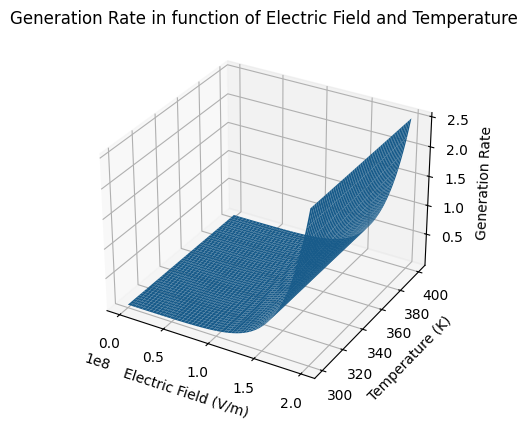

In [77]:
# represento la probabilidad de generación en función del campo eléctrico y la temperatura
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(electric_field, temperature)
Z = np.zeros((len(electric_field), len(temperature)))

for i in range(len(electric_field)):
    for j in range(len(temperature)):
        Z[i, j] = generation(1, electric_field[j], temperature[j])

ax.plot_surface(X, Y, Z)

ax.set_xlabel('Electric Field (V/m)')
ax.set_ylabel('Temperature (K)')
ax.set_zlabel('Generation Rate')
ax.set_title('Generation Rate in function of Electric Field and Temperature')

plt.show()

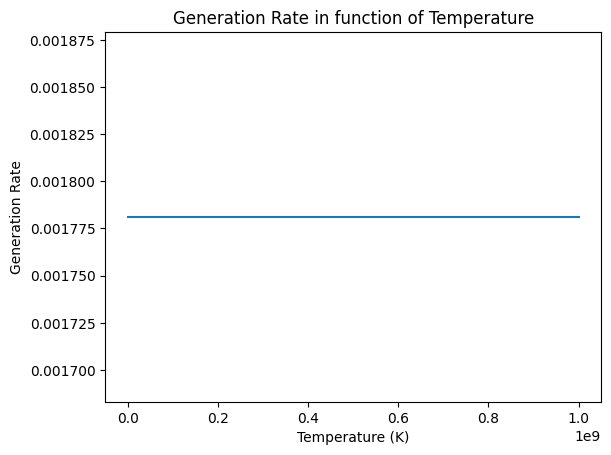

In [82]:
# represento la probabilidad de generación en función de la temperatura en dos dimensiones

fig, ax = plt.subplots()

ax.plot(electric_field, generation(1, electric_field, 320))
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Generation Rate')
ax.set_title('Generation Rate in function of Temperature')

plt.show()

832.6138471369986
